<center>
<img src="https://i.imgur.com/DW7NRwf.png" title="ElementalsAI" width=80%/>
</center>

# Introduction

Deep Learning has been very successful in solving many complex problems in the real world. However, solving most of these challenges requires data. Additionally, having data is not just enough. The data has to be cleansed, annotated, and organized. Moreover, data in many domains is not accessible due to privacy constraints (Especially in the medical domain). Hence it becomes pertinent to create models that can learn from a limited amount of data.

<br>

## Problem Statement:
In this task, you are given a small dataset of the microscopic view of the cells.

*Your goal is to build a model that accurately predicts the cell regions as shown in the **Label Image**.*

#### **Input Image**

<a href="https://imgur.com/aLDNHwu"><img src="https://i.imgur.com/aLDNHwu.png" title="source: imgur.com" /></a>

#### **Label Image**

<a href="https://imgur.com/s1mIkFE"><img src="https://i.imgur.com/s1mIkFE.png" title="source: imgur.com" /></a>


## Dataset:

The dataset contains 30 training images along with the labels.

[**Dataset Link**](https://drive.google.com/drive/folders/1678Tggykj46SpJZS9mKMKHw7YFmiGMc8?usp=sharing)


## Evaluation

Share the submission Jupyter/Colab notebook with the relevant explanation. code and models. We will evaluate your model on our **test dataset**.

<br><br>
****Note that this is an interview assignment & is not involved in the development of any software or solution.**

### Instructions

1. Add your solution in the provided code cells below.
2. A dataset folder has been shared with you to train and test.
2. You can use any framework to develop the solution (Pytorch, Keras, Tensorflow, JAX, Theano, Caffe etc.).
3. This assignment is a great medium to get to know you better. Please feel free to connect, interact & develop the solution. I would be more than willing to help you out in any issues or problems that you face while solving the challenge. You can connect us at get-hired@elementals.ai.
4. The goal of this task is to understand how you approach solving a problem.
5. Submission Files in a Zip file as attachment:
    - Colab Notebook with Solutions Approach and Code Solution.
    - Trained Model Link.
    - Any other necessary files.
5. **Submission deadline: Within 5 days of recieving the assignment, no later than 12 AM IST on the due date. The exact due date shall be mentioned in the email or the portal where you recieve the assignment.** (You can share the notebook as an attachment)

## Strict Rules & Policies:
1. Sharing of Notebook publicly on platforms like GitHub or elsewhere is a violation of the Code of Conduct and you will be personally liable for any legal repercussions.

## Explain the technique you will use to solve the problem in detail.

- Include any model architectures, equations, diagrams etc. that is required to explain how you are going to solve the problem.

To solve the problem of image segmentation for edge detection, you are using a U-Net-like architecture. Below, I'll provide explanations for the key components of the code, including the model architecture, data loading, training, and testing procedures.

**1) Model Architecture:**
This architecture consists of convolutional layers for feature extraction, max-pooling layers for downsampling, and upsampling layers for decoding. The final layer uses the sigmoid activation function to produce binary segmentation masks.

**2) Data Loading and Preprocessing:**
The load_data function loads image and label data from specified folders.
The preprocess_data function normalizes pixel values to the range [0, 1].

**3) Training:**
During training, the model is compiled with the Adam optimizer and binary cross-entropy loss.

**4) Testing:**
The trained model is loaded, and test images are processed and fed into the model for predictions.

**5) Visualization:**
The visualize_results function displays the original images and predicted edges side by side.
Note the **threshold is set to 0.4199** for accurately predicting edges.

**Output:** 

<a><img src="S2.png" title="source: imgur.com" /></a>

## Implement the solution below.

# Import Libraries

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.preprocessing.image import img_to_array, load_img
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from sklearn.model_selection import train_test_split
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# Load and Pre-Process Data

In [2]:
def load_data(data_path):
    images = []
    labels = []

    for filename in os.listdir(os.path.join(data_path, 'train-volume')):
        img = load_img(os.path.join(data_path, 'train-volume', filename), color_mode='grayscale')
        img_array = img_to_array(img)
        images.append(img_array)

    for filename_label in os.listdir(os.path.join(data_path, 'train-labels')):
        label = load_img(os.path.join(data_path, 'train-labels', filename_label), color_mode='grayscale')
        label_array = img_to_array(label)
        labels.append(label_array)

    return np.array(images), np.array(labels)

In [3]:
def canny_edge_detection(images):
    edges = []
    for img in images:
        img_gray = cv2.cvtColor(np.uint8(img), cv2.COLOR_GRAY2BGR)
        edges.append(cv2.Canny(img_gray, 50, 150)) 
    return np.array(edges)

data_path = 'dataset/'
train_images, train_labels = load_data(data_path)

train_labels_canny = canny_edge_detection(train_images)

train_images = train_images / 255.0
train_labels = train_labels / 255.0
train_labels_canny = train_labels_canny / 255.0


In [4]:

from sklearn.model_selection import train_test_split


X_train, X_val, y_train, y_val = train_test_split(train_images, train_labels_canny, test_size=0.2, random_state=42)



# Create and Training of Model

In [5]:
def build_model():
    input_layer = Input(shape=(512, 512, 1))

    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(input_layer)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    up1 = UpSampling2D(size=(2, 2))(pool1)
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(up1)

    model = Model(inputs=input_layer, outputs=decoded)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    return model

model = build_model()

model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32)

model.save('solution_2_model.h5')





Epoch 1/10


1/1 [==============================] - 19s 19s/step - loss: 0.6837 - accuracy: 0.6317 - val_loss: 0.6814 - val_accuracy: 0.6275
Epoch 2/10
1/1 [==============================] - 6s 6s/step - loss: 0.6805 - accuracy: 0.6321 - val_loss: 0.6787 - val_accuracy: 0.6282
Epoch 3/10
1/1 [==============================] - 5s 5s/step - loss: 0.6776 - accuracy: 0.6329 - val_loss: 0.6761 - val_accuracy: 0.6284
Epoch 4/10
1/1 [==============================] - 5s 5s/step - loss: 0.6749 - accuracy: 0.6330 - val_loss: 0.6738 - val_accuracy: 0.6284
Epoch 5/10
1/1 [==============================] - 5s 5s/step - loss: 0.6724 - accuracy: 0.6330 - val_loss: 0.6716 - val_accuracy: 0.6284
Epoch 6/10
1/1 [==============================] - 5s 5s/step - loss: 0.6701 - accuracy: 0.6330 - val_loss: 0.6697 - val_accuracy: 0.6284
Epoch 7/10
1/1 [==============================] - 5s 5s/step - loss: 0.6680 - accuracy: 0.6330 - val_loss: 0.6679 - val_accuracy: 0.6284
Epoch 8/10
1/1 [==================

E:\Softwares\Anaconda\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


# Evaluate the Model

In [6]:
test_images, test_labels = load_data('dataset/')
test_labels_canny = canny_edge_detection(test_images)
test_images = test_images / 255.0
test_labels = test_labels / 255.0
test_labels_canny = test_labels_canny / 255.0


In [7]:
eval_result = model.evaluate(test_images, test_labels_canny)
print(f"Test Loss: {eval_result[0]}, Test Accuracy: {eval_result[1]}")

1/1 [==============================] - 1s 1s/step - loss: 0.6622 - accuracy: 0.6321
Test Loss: 0.6622121334075928, Test Accuracy: 0.6320942044258118


# Test the Model

1/1 [==============================] - 0s 104ms/step


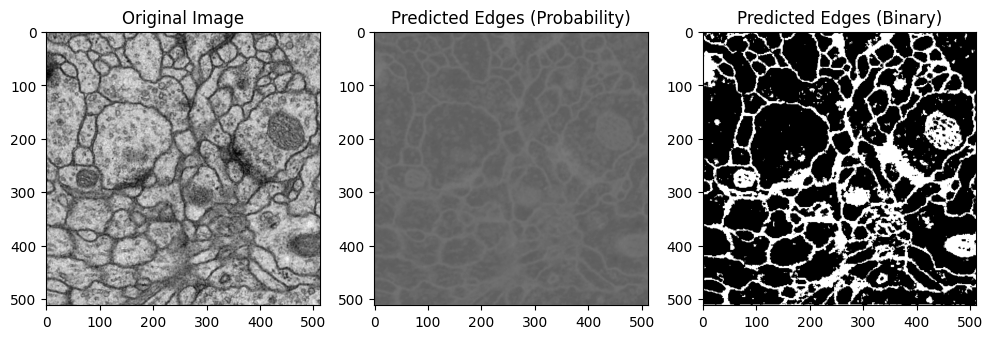

In [23]:
new_image = load_img('train-volume/train-volume_0.tif', color_mode='grayscale')
new_image_array = img_to_array(new_image)
new_image_array = new_image_array / 255.0

new_image_array = np.reshape(new_image_array, (1, 512, 512, 1))

predictions = model.predict(new_image_array)
threshold = 0.4199 
binary_predictions = (predictions > threshold).astype(np.uint8)

plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.imshow(new_image_array[0, :, :, 0], cmap='gray')
plt.title('Original Image')

plt.subplot(1, 3, 2)
plt.imshow(predictions[0, :, :, 0], cmap='gray', vmin=0, vmax=1)
plt.title('Predicted Edges (Probability)')

plt.subplot(1, 3, 3)
plt.imshow(binary_predictions[0, :, :, 0], cmap='gray', vmin=0, vmax=1)
plt.title('Predicted Edges (Binary)')

plt.show()

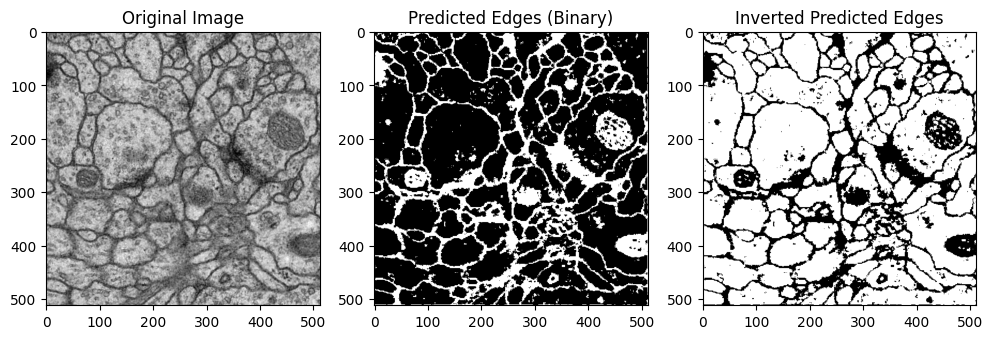

In [22]:
# Apply threshold to create a binary image
threshold = 0.4199 # Adjust this threshold as needed
binary_predictions = (predictions > threshold).astype(np.uint8)

# Invert the binary image
binary_predictions_inverted = 1 - binary_predictions

# Display the original image and inverted predicted edges
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.imshow(new_image_array[0, :, :, 0], cmap='gray')
plt.title('Original Image')

plt.subplot(1, 3, 2)
plt.imshow(binary_predictions[0, :, :, 0], cmap='gray', vmin=0, vmax=1)
plt.title('Predicted Edges (Binary)')

plt.subplot(1, 3, 3)
plt.imshow(binary_predictions_inverted[0, :, :, 0], cmap='gray', vmin=0, vmax=1)
plt.title('Inverted Predicted Edges')

plt.show()
